<a href="https://colab.research.google.com/github/haramirfan343-alt/AI-Product-imaga-optimizer/blob/main/research_file_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (14).zip'
extract_dir = '/content/unzipped_archive'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File unzipped to: {extract_dir}")
!ls -F {extract_dir}

File unzipped to: /content/unzipped_archive
ct_brain.csv  files/


### Verify Zip File Validity

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (14).zip' # Using the path from your previous attempt

if os.path.exists(zip_file_path):
    if zipfile.is_zipfile(zip_file_path):
        print(f"'{zip_file_path}' is a valid zip archive.")
    else:
        print(f"'{zip_file_path}' is NOT a valid zip archive. This confirms the 'BadZipFile' error.")
        print("Please ensure the file is not corrupted and is a proper .zip file.")
else:
    print(f"Error: The file '{zip_file_path}' does not exist.")


'/content/archive (14).zip' is a valid zip archive.


In [ ]:
import os

files_dir = os.path.join(extract_dir, 'files')

if os.path.exists(files_dir) and os.path.isdir(files_dir):
    print(f"Contents of {files_dir}:")
    !ls -F "{files_dir}"
else:
    print(f"Directory {files_dir} not found.")


Contents of /content/unzipped_archive/files:
aneurysm/  cancer/  tumor/


## Sample Images from Each Category (Up to 3 per folder)

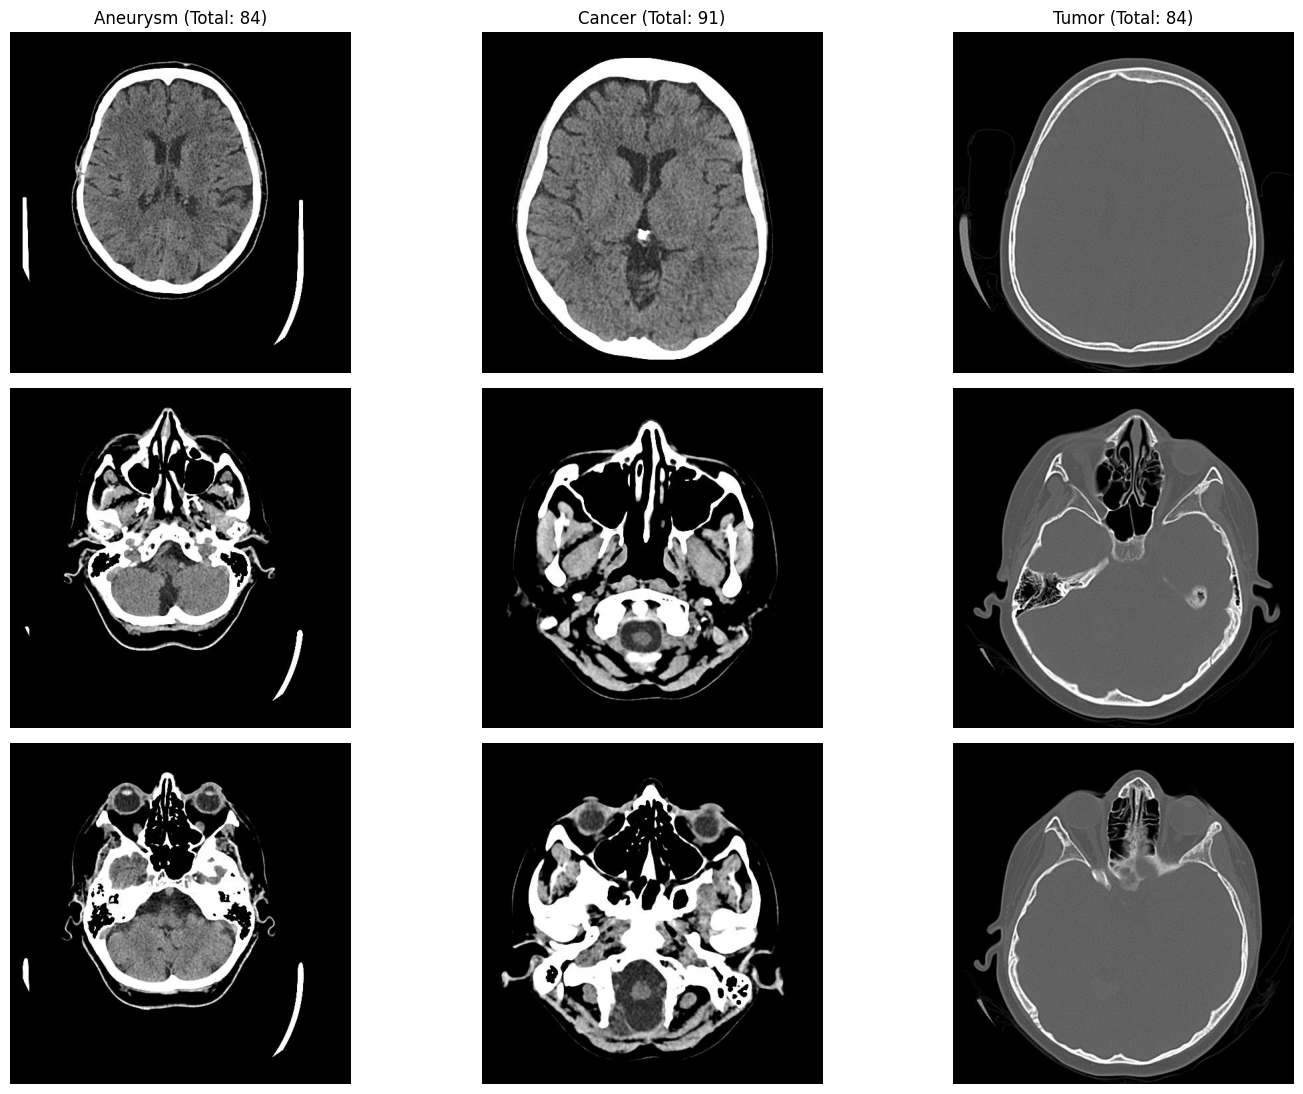

## Image Count per Folder

/tmp/ipykernel_64970/574552031.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=image_counts_series.index, y=image_counts_series.values, palette='viridis')


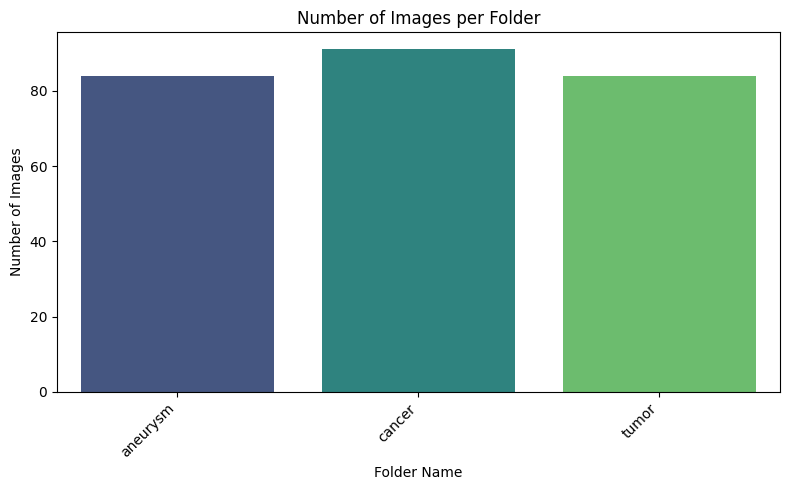

In [ ]:
from IPython.display import Image, display, Markdown
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2 # For loading images into matplotlib

image_folders = ['aneurysm', 'cancer', 'tumor']
all_folder_image_counts = {}
folder_image_samples = {folder: [] for folder in image_folders}
max_images_per_column = 3 # Define how many images to show per folder

# First, gather all image file paths and counts
for folder_name in image_folders:
    folder_path = os.path.join(files_dir, folder_name)

    image_files = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        image_files.extend(glob.glob(os.path.join(folder_path, '**', ext), recursive=True))

    all_folder_image_counts[folder_name] = len(image_files)
    folder_image_samples[folder_name] = image_files[:max_images_per_column] # Get up to max_images_per_column sample images

# --- Display images side-by-side using Matplotlib ---
display(Markdown(f"## Sample Images from Each Category (Up to {max_images_per_column} per folder)"))

# Calculate dynamic figure height based on number of images per column
fig_height = 4 * max_images_per_column # Adjust height per image
fig, axes = plt.subplots(max_images_per_column, len(image_folders), figsize=(15, fig_height))

# Flatten axes for easier iteration if there's only one row of images
if max_images_per_column == 1:
    axes = [axes]

for col_idx, folder_name in enumerate(image_folders):
    # Set title for the top of each column
    axes[0][col_idx].set_title(f"{folder_name.capitalize()} (Total: {all_folder_image_counts[folder_name]})", fontsize=12)

    for row_idx in range(max_images_per_column):
        ax = axes[row_idx][col_idx]
        if row_idx < len(folder_image_samples[folder_name]):
            img_path = folder_image_samples[folder_name][row_idx]
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.axis('off') # Hide axes ticks
        else:
            ax.axis('off') # Hide empty subplots

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# --- Display image counts by graph ---
display(Markdown("## Image Count per Folder"))

image_counts_series = pd.Series(all_folder_image_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=image_counts_series.index, y=image_counts_series.values, palette='viridis')
plt.title('Number of Images per Folder')
plt.xlabel('Folder Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np

# Combine all image paths and create labels
all_image_paths = []
all_image_labels = []

label_mapping = {folder: idx for idx, folder in enumerate(image_folders)}

for folder_name in image_folders:
    folder_path = os.path.join(files_dir, folder_name)
    current_image_files = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        current_image_files.extend(glob.glob(os.path.join(folder_path, '**', ext), recursive=True))

    all_image_paths.extend(current_image_files)
    all_image_labels.extend([label_mapping[folder_name]] * len(current_image_files))

# Create a Pandas DataFrame
df_images = pd.DataFrame({
    'path': all_image_paths,
    'label': all_image_labels
})

display(df_images.head())
display(df_images['label'].value_counts())

# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(df_images['path'], df_images['label'], test_size=0.2, random_state=42, stratify=df_images['label'])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train) # 0.25 * 0.8 = 0.2

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

,path,label
0,/content/unzipped_archive/files/aneurysm/50.jpg,0
1,/content/unzipped_archive/files/aneurysm/20.jpg,0
2,/content/unzipped_archive/files/aneurysm/25.jpg,0
3,/content/unzipped_archive/files/aneurysm/67.jpg,0
4,/content/unzipped_archive/files/aneurysm/48.jpg,0


,count
label,
1,91
0,84
2,84


Training samples: 155
Validation samples: 52
Test samples: 52


### Image Preprocessing Function

Datasets created successfully with augmentation applied to training data!


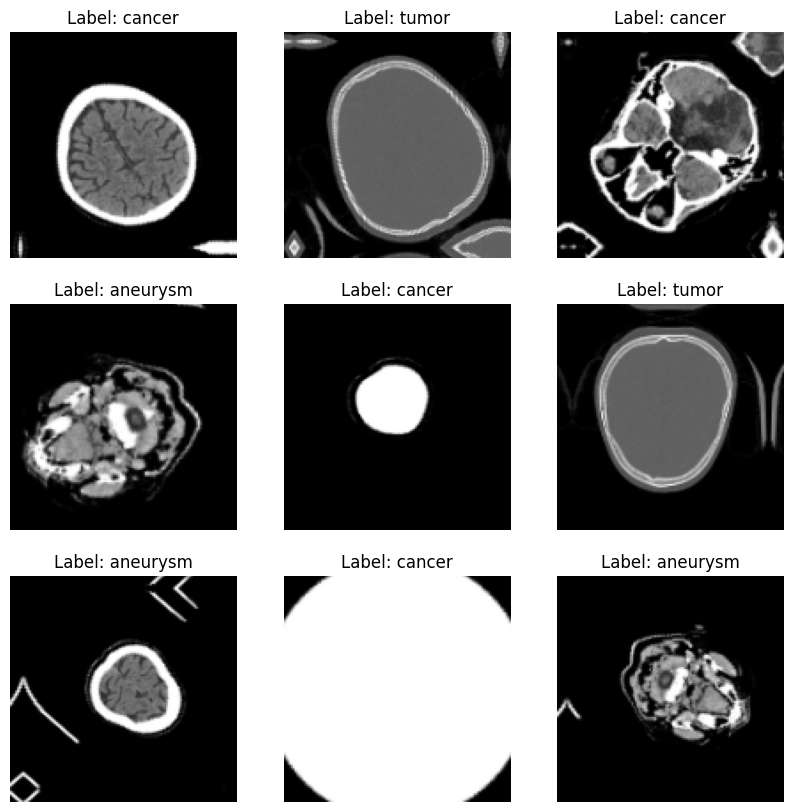

In [ ]:
# Define image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
NUM_CLASSES = len(image_folders)

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3) # Assuming JPEG format, adjust if needed
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
    return image, label

# Create tf.data.Dataset objects
def create_dataset(image_paths, labels, shuffle=True, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: # Apply augmentation only for training data
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(X_train, y_train, shuffle=True, augment=True) # Apply augmentation to training data
val_ds = create_dataset(X_val, y_val, shuffle=False, augment=False)
test_ds = create_dataset(X_test, y_test, shuffle=False, augment=False)

print("Datasets created successfully with augmentation applied to training data!")

# Display a batch of preprocessed images to verify
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {list(label_mapping.keys())[labels[i].numpy()]}")
        plt.axis("off")
    plt.show()
    break

## Model Definition and Training

In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax') # Output layer for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

print("Model defined and compiled successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Model defined and compiled successfully!


### Train the Model

In [ ]:
EPOCHS = 20 # Increased the number of epochs

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("Model training complete!")

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 996ms/step - accuracy: 0.4387 - loss: 1.1948 - val_accuracy: 0.3846 - val_loss: 0.9820
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 972ms/step - accuracy: 0.3935 - loss: 1.0171 - val_accuracy: 0.5577 - val_loss: 0.9431
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5419 - loss: 0.9042 - val_accuracy: 0.4615 - val_loss: 0.7616
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5097 - loss: 0.8369 - val_accuracy: 0.6731 - val_loss: 0.6618
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7161 - loss: 0.7160 - val_accuracy: 0.7308 - val_loss: 0.6205
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 907ms/step - accuracy: 0.6581 - loss: 0.6276 - val_accuracy: 0.8077 - val_loss: 0.5315
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7613 - loss: 0.5622 - val_accuracy: 0.8269 - val_loss: 0.3919
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 955ms/step - accuracy: 0.8581 - loss: 0.4220 - val_accuracy: 0.8462 - val_loss: 0.5571
Epo

### Evaluate the Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9038 - loss: 0.3496
Test Loss: 0.3496
Test Accuracy: 0.9038


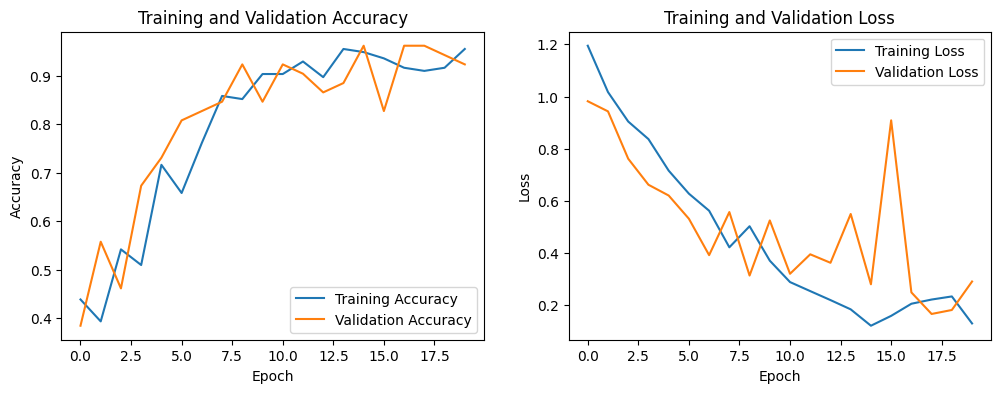

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## Manual Federated Learning Simulation

Since TensorFlow Federated had installation issues, we'll set up a manual simulation. This involves:

1.  **Redefining the Keras Model:** A function `create_keras_model` will be used to ensure each client and the central server can instantiate the same model architecture.
2.  **Custom `FederatedClient` Class:** Each instance of this class will represent a virtual client, holding its local data and responsible for local model updates.
3.  **Data Distribution:** `X_train` and `y_train` will be split into `NUM_CLIENTS` (5) subsets, with each subset assigned to a client.
4.  **Federated Training Loop:** A central server will coordinate rounds of communication, distributing global model weights, collecting local updates from clients, and aggregating them to update the global model.

In [ ]:
from tensorflow.keras import layers, models

# Redefine the create_keras_model function as it was likely in a deleted TFF cell
def create_keras_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax') # Output layer for multi-class classification
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Keras model creation function defined.")

Keras model creation function defined.


### Model Definition for Federated Learning (Pre-trained Models)

In [ ]:
from tensorflow.keras.applications import MobileNetV2, MobileNetV3Large, ResNet50, VGG16, DenseNet121
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def create_model_base(base_model_class, name):
    base_model = base_model_class(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                                  include_top=False,  # Don't include the classifier layers of the pre-trained model
                                  weights='imagenet') # Load weights pre-trained on ImageNet

    # Freeze the base model layers to prevent re-training during initial federated rounds
    # This helps in quickly adapting the top layers to our specific dataset.
    base_model.trainable = False

    # Add custom top layers for classification
    x = base_model.output
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs, name=name)

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_mobilenet_v2_model():
    return create_model_base(MobileNetV2, "MobileNetV2_FL")

def create_mobilenet_v3_large_model():
    return create_model_base(MobileNetV3Large, "MobileNetV3Large_FL")

def create_resnet50_model():
    return create_model_base(ResNet50, "ResNet50_FL")

def create_vgg16_model():
    return create_model_base(VGG16, "VGG16_FL")

def create_densenet121_model():
    return create_model_base(DenseNet121, "DenseNet121_FL")

print("Model creation functions for pre-trained models defined.")

Model creation functions for pre-trained models defined.


In [ ]:
# Define the number of clients
NUM_CLIENTS = 5

# Split the training data (X_train, y_train) into 5 virtual client nodes
# np.array_split handles cases where the division isn't perfectly even
X_train_splits = np.array_split(X_train, NUM_CLIENTS)
y_train_splits = np.array_split(y_train, NUM_CLIENTS)

print(f"Original training samples: {len(X_train)}")
for i, (x_split, y_split) in enumerate(zip(X_train_splits, y_train_splits)):
    print(f"Client {i+1} data size: {len(x_split)}")

# Define a custom FederatedClient class
class FederatedClient:
    def __init__(self, client_id, local_X_train, local_y_train, model_fn):
        self.client_id = client_id
        self.local_X_train = local_X_train
        self.local_y_train = local_y_train

        # Create a tf.data.Dataset for this client's local data
        self.local_dataset = create_dataset(local_X_train, local_y_train, shuffle=True, augment=True)

        # Initialize a local model for the client using the provided model_fn
        self.local_model = model_fn()
        print(f"Client {self.client_id} initialized with {len(local_X_train)} local samples.")

    def set_global_weights(self, global_weights):
        """Sets the client's local model weights to the received global weights."""
        self.local_model.set_weights(global_weights)

    def train_local_model(self, epochs=1):
        """Trains the client's local model on its local data and returns updated weights and metrics."""
        print(f"Client {self.client_id} training locally for {epochs} epochs...")
        history = self.local_model.fit(
            self.local_dataset,
            epochs=epochs,
            verbose=0 # Suppress verbose output for cleaner simulation
        )
        local_weights = self.local_model.get_weights()
        local_metrics = history.history
        print(f"Client {self.client_id} local training complete. Loss: {local_metrics['loss'][-1]:.4f}, Accuracy: {local_metrics['accuracy'][-1]:.4f}")
        return local_weights, local_metrics

# Note: The instantiation of clients will now happen inside the federated loop,
# passing the specific model_fn for each model.

Original training samples: 155
Client 1 data size: 31
Client 2 data size: 31
Client 3 data size: 31
Client 4 data size: 31
Client 5 data size: 31


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


### Federated Training Loop

In [ ]:
print("Starting Federated Learning Simulation for Multiple Models...")

# Define the list of models to train
models_to_train = [
    ("MobileNetV2", create_mobilenet_v2_model),
    ("MobileNetV3Large", create_mobilenet_v3_large_model),
    ("ResNet50", create_resnet50_model),
    ("VGG16", create_vgg16_model),
    ("DenseNet121", create_densenet121_model)
]

# Parameters for Federated Learning
FEDERATED_ROUNDS = 20 # User requested not more than 20 epochs
LOCAL_EPOCHS = 1

# Store results for comparison
all_models_results = {}

for model_name, model_fn in models_to_train:
    print(f"\n{'='*50}\nStarting Federated Training for Model: {model_name}\n{'='*50}")

    # 1. Initialize Global Model for the current architecture
    global_model = model_fn()
    print(f"Global {model_name} model initialized.")

    # Instantiate the Federated Clients for the current model architecture
    clients = []
    for i in range(NUM_CLIENTS):
        client = FederatedClient(f'client_{i+1}', X_train_splits[i], y_train_splits[i], model_fn)
        clients.append(client)

    round_accuracies = []
    round_losses = []

    for round_num in range(FEDERATED_ROUNDS):
        print(f"\n--- Federated Round {round_num + 1}/{FEDERATED_ROUNDS} ({model_name}) ---")

        # 2. Server sends global model weights to clients
        global_weights = global_model.get_weights()
        for client in clients:
            client.set_global_weights(global_weights)

        # 3. Clients perform local training
        client_updates = [] # List to store (weights, num_samples) from each client
        for client in clients:
            local_weights, _ = client.train_local_model(epochs=LOCAL_EPOCHS)
            num_local_samples = len(client.local_X_train)
            client_updates.append((local_weights, num_local_samples))

        # 4. Server aggregates client updates (Weighted Averaging)
        total_samples = sum([num_samples for _, num_samples in client_updates])
        aggregated_weights = [np.zeros_like(w) for w in global_weights]

        for local_weights, num_samples in client_updates:
            weight_ratio = num_samples / total_samples
            for i, layer_weights in enumerate(local_weights):
                aggregated_weights[i] += weight_ratio * layer_weights

        # 5. Server updates its global model with aggregated weights
        global_model.set_weights(aggregated_weights)
        print(f"Global {model_name} model updated with aggregated client weights.")

        # 6. Evaluate the global model on the test dataset after each round
        loss, accuracy = global_model.evaluate(test_ds, verbose=0)
        round_losses.append(loss)
        round_accuracies.append(accuracy)
        print(f"Global {model_name} Model Test Loss after Round {round_num + 1}: {loss:.4f}")
        print(f"Global {model_name} Model Test Accuracy after Round {round_num + 1}: {accuracy:.4f}")

    # Store results for the current model
    all_models_results[model_name] = {
        "accuracies": round_accuracies,
        "losses": round_losses,
        "final_weights": global_model.get_weights(), # Store final weights
        "model_fn": model_fn # Store the model creation function for later use
    }

    print(f"\n{'='*50}\nFederated Learning for {model_name} Complete!\n{'='*50}")
    final_loss, final_accuracy = global_model.evaluate(test_ds)
    print(f"\nFinal Global {model_name} Model Test Loss: {final_loss:.4f}")
    print(f"Final Global {model_name} Model Test Accuracy: {final_accuracy:.4f}")

print("\nFederated Learning Simulation for All Models Complete!")

# Optional: Display a summary of all model results
print("\n--- Summary of All Model Results ---")
for model_name, results in all_models_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Final Test Accuracy: {results['accuracies'][-1]:.4f}")
    print(f"  Final Test Loss: {results['losses'][-1]:.4f}")

Starting Federated Learning Simulation for Multiple Models...

Starting Federated Training for Model: MobileNetV2
Global MobileNetV2 model initialized.
Client client_1 initialized with 31 local samples.
Client client_2 initialized with 31 local samples.
Client client_3 initialized with 31 local samples.
Client client_4 initialized with 31 local samples.
Client client_5 initialized with 31 local samples.

--- Federated Round 1/20 (MobileNetV2) ---
Client client_1 training locally for 1 epochs...
Client client_1 local training complete. Loss: 2.6759, Accuracy: 0.2258
Client client_2 training locally for 1 epochs...
Client client_2 local training complete. Loss: 1.8926, Accuracy: 0.3226
Client client_3 training locally for 1 epochs...
Client client_3 local training complete. Loss: 2.5782, Accuracy: 0.2581
Client client_4 training locally for 1 epochs...
Client client_4 local training complete. Loss: 1.7944, Accuracy: 0.2581
Client client_5 training locally for 1 epochs...


Client client_5 local training complete. Loss: 2.5345, Accuracy: 0.2258
Global MobileNetV2 model updated with aggregated client weights.


Global MobileNetV2 Model Test Loss after Round 1: 13.1053
Global MobileNetV2 Model Test Accuracy after Round 1: 0.3269

--- Federated Round 2/20 (MobileNetV2) ---
Client client_1 training locally for 1 epochs...
Client client_1 local training complete. Loss: 11.1679, Accuracy: 0.3871
Client client_2 training locally for 1 epochs...
Client client_2 local training complete. Loss: 12.4905, Accuracy: 0.2258
Client client_3 training locally for 1 epochs...
Client client_3 local training complete. Loss: 8.8505, Accuracy: 0.4194
Client client_4 training locally for 1 epochs...
Client client_4 local training complete. Loss: 14.1867, Accuracy: 0.1613
Client client_5 training locally for 1 epochs...
Client client_5 local training complete. Loss: 10.7333, Accuracy: 0.4194
Global MobileNetV2 model updated with aggregated client weights.
Global MobileNetV2 Model Test Loss after Round 2: 1.9221
Global MobileNetV2 Model Test Accuracy after Round 2: 0.6154

--- Federated Round 3/20 (MobileNetV2) ---
C

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Global MobileNetV3Large model initialized.
Client client_1 initialized with 31 local samples.
Client client_2 initialized with 31 local samples.
Client client_3 initialized with 31 local samples.
Client client_4 initialized with 31 local samples.
Client client_5 initialized with 31 local samples.

--- Federated Round 1/20 (MobileNetV3Large) ---
Client client_1 training locally for 1 epochs...
Client client_1 local training complete. Loss: 1.2514, Accuracy: 0.4194
Client client_2 training locally for 1 epochs...
Client client_2 local training complete. Loss: 1.4198, Accuracy: 0.2258
Client client_3 training locally for 1 epochs...
Client client_3 local training complete. Loss: 1.1847, Accuracy: 0.4516
Client client_4 training locally for 1 epochs...
Client client_4 local training complete. Loss: 1.4766, Accuracy: 0.3548
Client client_5 training locally for 1 epochs...
Client client_5 local training complete. Loss: 1.3193, Accuracy: 0.2581
Global MobileNetV3Large model updated with aggre

## Classification Reports for All Models

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# Map integer labels back to original class names for the report
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
class_names = [reverse_label_mapping[i] for i in sorted(reverse_label_mapping.keys())]

for model_name, results in all_models_results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report for: {model_name}")
    print(f"{'='*50}")

    # Recreate the model using its function and load the final weights
    final_model = results['model_fn']()
    final_model.set_weights(results['final_weights'])

    # Collect true labels and predictions for the test dataset
    y_true_list = []
    y_pred_list = []

    for images, labels in test_ds:
        predictions = final_model.predict(images, verbose=0)
        y_pred = np.argmax(predictions, axis=1)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(y_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)

    # Generate and print the classification report
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    print(report)



Classification Report for: MobileNetV2
              precision    recall  f1-score   support

    aneurysm       1.00      0.82      0.90        17
      cancer       0.86      1.00      0.92        18
       tumor       1.00      1.00      1.00        17

    accuracy                           0.94        52
   macro avg       0.95      0.94      0.94        52
weighted avg       0.95      0.94      0.94        52


Classification Report for: MobileNetV3Large


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


              precision    recall  f1-score   support

    aneurysm       0.79      0.65      0.71        17
      cancer       0.74      0.94      0.83        18
       tumor       1.00      0.88      0.94        17

    accuracy                           0.83        52
   macro avg       0.84      0.82      0.83        52
weighted avg       0.84      0.83      0.83        52


Classification Report for: ResNet50


              precision    recall  f1-score   support

    aneurysm       0.53      0.59      0.56        17
      cancer       0.68      0.72      0.70        18
       tumor       0.93      0.76      0.84        17

    accuracy                           0.69        52
   macro avg       0.71      0.69      0.70        52
weighted avg       0.71      0.69      0.70        52


Classification Report for: VGG16
              precision    recall  f1-score   support

    aneurysm       0.94      0.94      0.94        17
      cancer       0.95      1.00      0.97        18
       tumor       1.00      0.94      0.97        17

    accuracy                           0.96        52
   macro avg       0.96      0.96      0.96        52
weighted avg       0.96      0.96      0.96        52


Classification Report for: DenseNet121
              precision    recall  f1-score   support

    aneurysm       0.89      0.94      0.91        17
      cancer       0.95      1.00      0.97        18
 

### Comparison of Model Accuracies

/tmp/ipykernel_64970/949803178.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


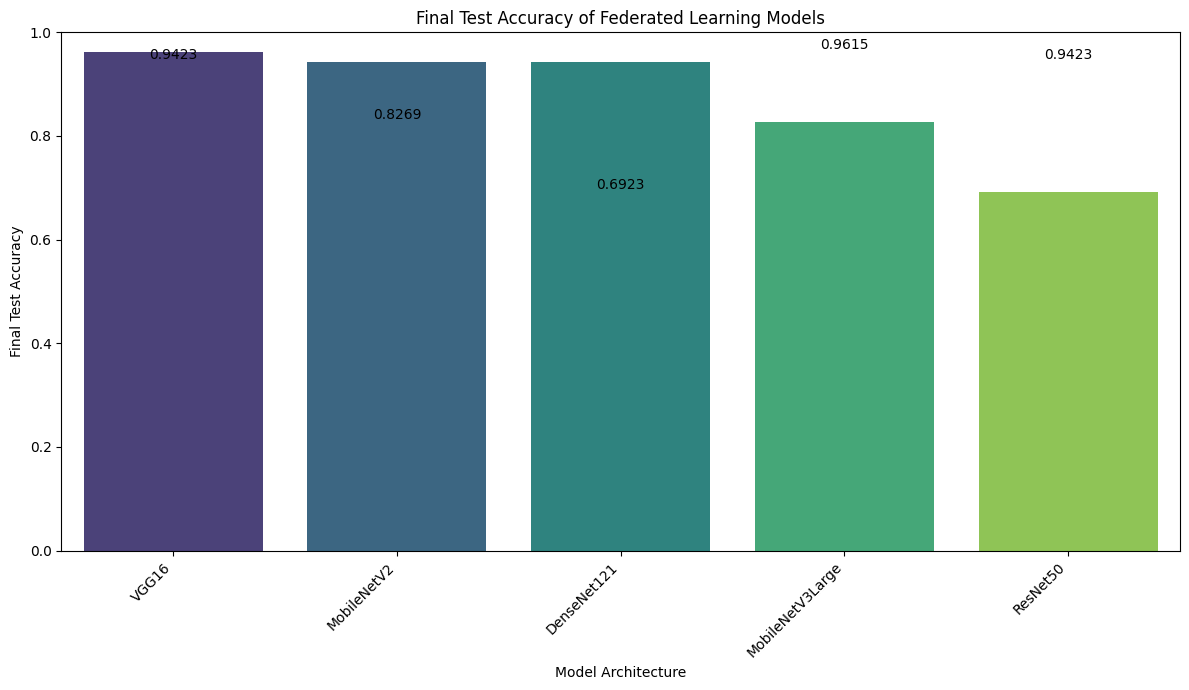

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract model names and their final accuracies
model_names = []
final_accuracies = []

for model_name, results in all_models_results.items():
    model_names.append(model_name)
    final_accuracies.append(results['accuracies'][-1]) # Get the last accuracy from the list

# Create a DataFrame for easier plotting
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': final_accuracies
})

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Final Test Accuracy of Federated Learning Models')
plt.xlabel('Model Architecture')
plt.ylabel('Final Test Accuracy')
plt.ylim(0, 1) # Accuracy ranges from 0 to 1
plt.xticks(rotation=45, ha='right')

# Add accuracy values on top of the bars
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Accuracy'], f'{row['Accuracy']:.4f}', color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

## Confusion Matrices for All Models

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


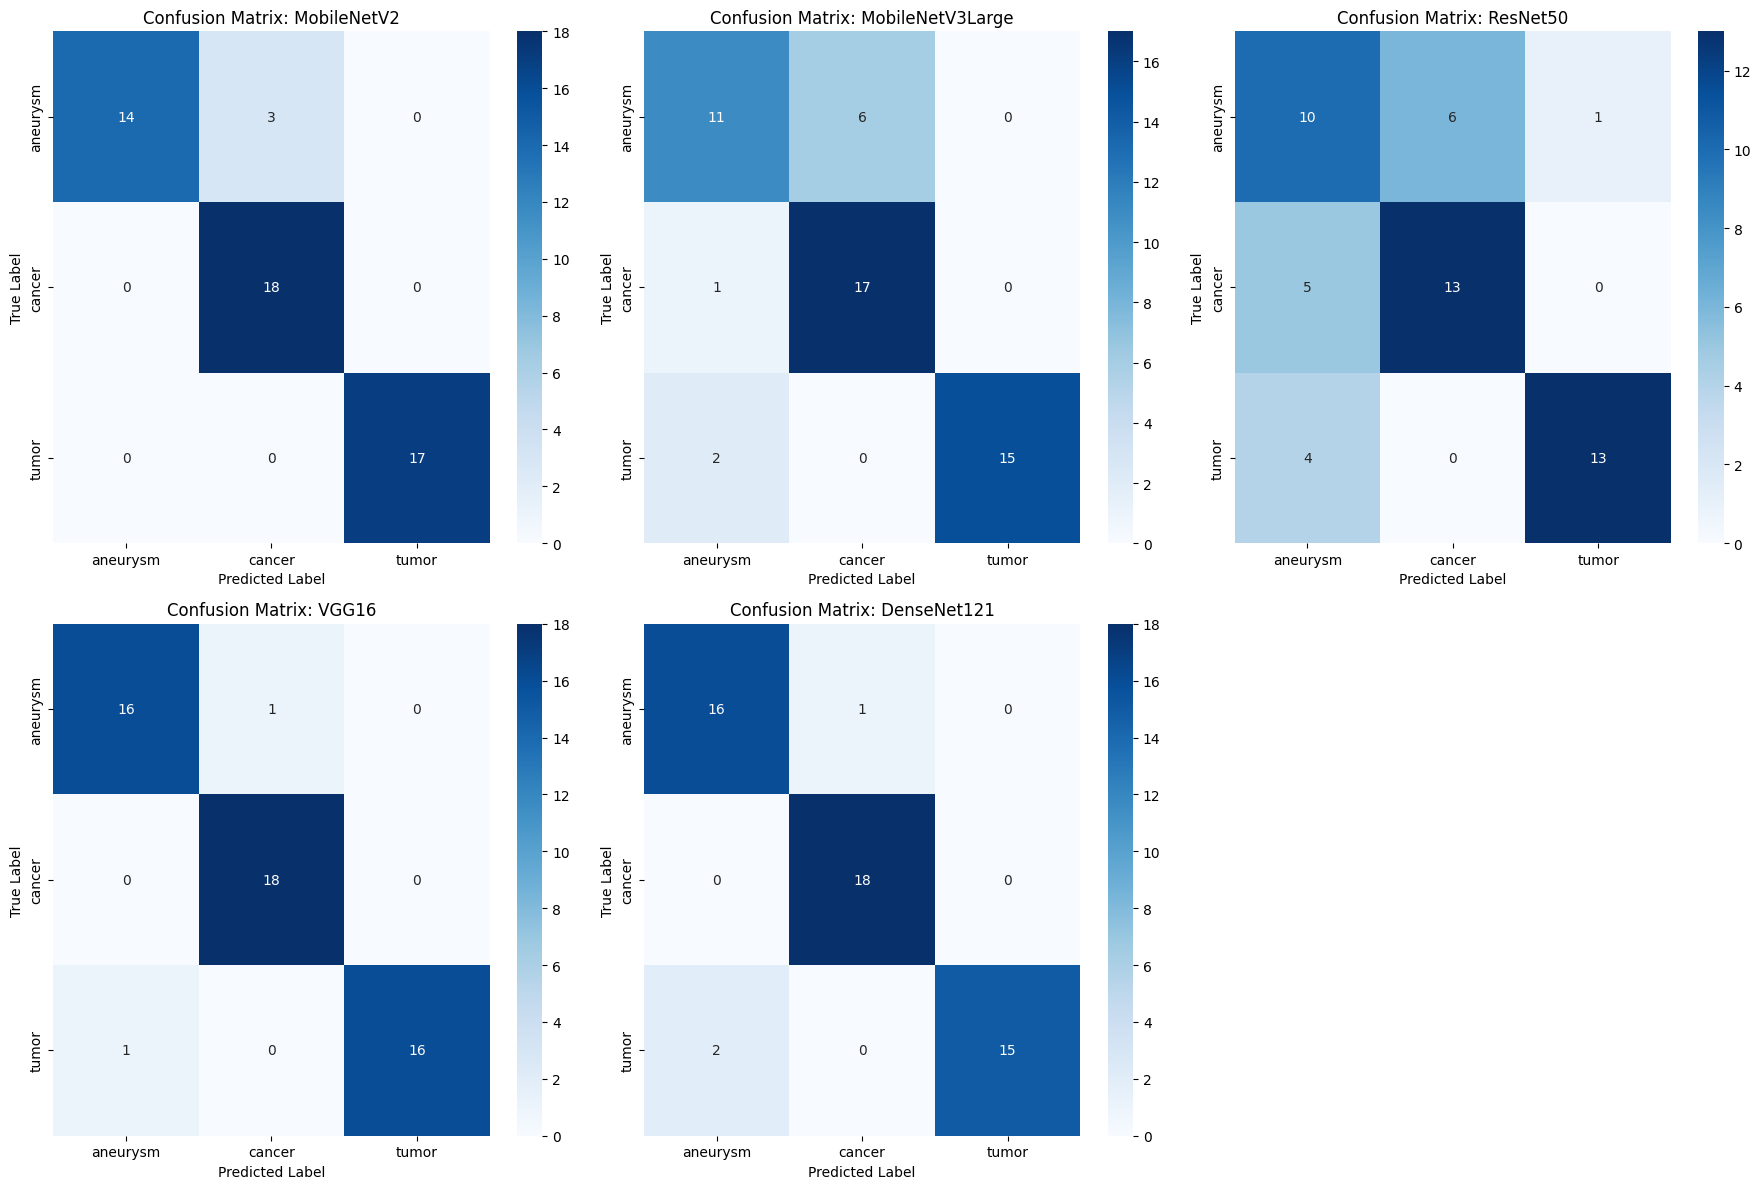

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure class_names and reverse_label_mapping are defined (if not already)
if 'reverse_label_mapping' not in globals():
    # Assuming label_mapping is available from earlier preprocessing
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    class_names = [reverse_label_mapping[i] for i in sorted(reverse_label_mapping.keys())]

# Determine subplot layout for 5 models
num_models = len(all_models_results)
rows = 2
cols = 3 # A 2x3 grid works well for 5 or 6 plots

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (model_name, results) in enumerate(all_models_results.items()):
    # Recreate the model using its function and load the final weights
    final_model = results['model_fn']()
    final_model.set_weights(results['final_weights'])

    y_true_list = []
    y_pred_list = []

    for images, labels in test_ds:
        predictions = final_model.predict(images, verbose=0)
        y_pred = np.argmax(predictions, axis=1)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(y_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plotting on the current subplot axis
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix: {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## XAI: Grad-CAM for VGG16 Model

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize the regions of an image that a convolutional neural network uses to make a prediction. We will apply it to the best-performing model, VGG16, with an example from the test set.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input, decode_predictions
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradients of the top predicted class for our image with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is" with respect to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Apply colormap to the heatmap
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return img, superimposed_img

print("Grad-CAM functions defined.")

Grad-CAM functions defined.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradients of the top predicted class for our image with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is" with respect to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Apply colormap to the heatmap
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return img, superimposed_img

print("Grad-CAM functions re-defined.")

Grad-CAM functions re-defined.


### Applying Grad-CAM to VGG16

Identified last convolutional layer for VGG16: block5_conv3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step

Analyzing image: /content/unzipped_archive/files/tumor/77.jpg
True label: tumor
Predicted label: aneurysm (Confidence: 0.7915)


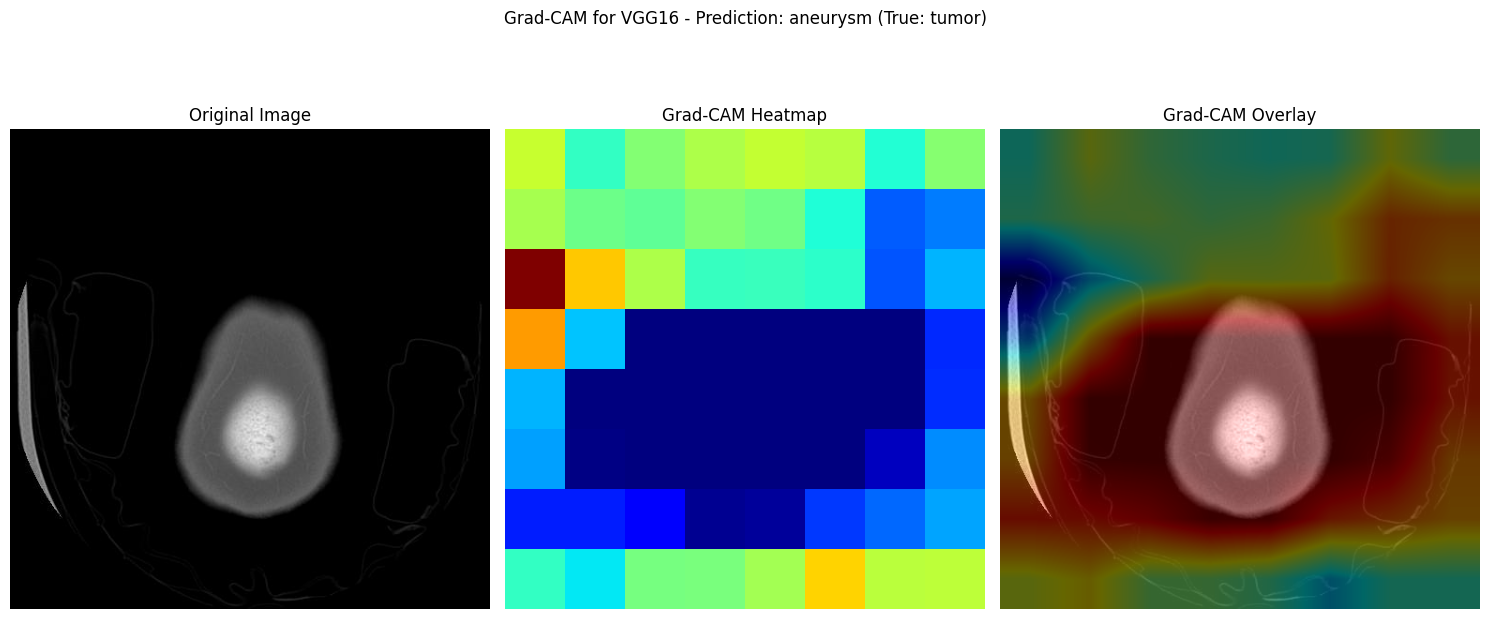

In [ ]:



# Get the VGG16 model from the results
vgg16_model_info = all_models_results['VGG16']
vgg16_fl_model = vgg16_model_info['model_fn']()
vgg16_fl_model.set_weights(vgg16_model_info['final_weights'])

# Find the name of the last convolutional layer in VGG16
# A common last convolutional layer for VGG16 is 'block5_conv3'.
# Let's verify by iterating through the layers if possible, but use block5_conv3 as a primary candidate.

last_conv_layer_name = None
for layer in reversed(vgg16_fl_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name:
    print(f"Identified last convolutional layer for VGG16: {last_conv_layer_name}")
else:
    print("Could not find a convolutional layer in the VGG16 model. Falling back to 'block5_conv3'.")
    last_conv_layer_name = 'block5_conv3' # Fallback to a commonly known last conv layer name if automatic detection fails

# Select an example image from the test set
example_index = 0 # You can change this index to try different images
example_img_path = X_test.iloc[example_index]
example_true_label = y_test.iloc[example_index]

# Preprocess the image for the model
img = tf.io.read_file(example_img_path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
img_array = tf.expand_dims(img, 0) / 255.0 # Normalize to [0,1] and add batch dimension

# Make prediction
predictions = vgg16_fl_model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = reverse_label_mapping[predicted_class_index]
true_class_name = reverse_label_mapping[example_true_label]

print(f"\nAnalyzing image: {example_img_path}")
print(f"True label: {true_class_name}")
print(f"Predicted label: {predicted_class_name} (Confidence: {predictions[0][predicted_class_index]:.4f})")

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, vgg16_fl_model, last_conv_layer_name, pred_index=predicted_class_index)

# Display Grad-CAM
original_img, superimposed_img = display_gradcam(example_img_path, heatmap)

plt.figure(figsize=(15, 7))
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.suptitle(f"Grad-CAM for VGG16 - Prediction: {predicted_class_name} (True: {true_class_name})")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## XAI: LIME for VGG16 Model

LIME (Local Interpretable Model-agnostic Explanations) provides local explanations for individual predictions. It approximates the underlying model's behavior around the prediction with an interpretable model (like a linear model) to highlight features important for that specific prediction.

In [ ]:
!pip install lime

import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries

# Get the VGG16 model from the results
vgg16_model_info = all_models_results['VGG16']
vgg16_fl_model = vgg16_model_info['model_fn']()
vgg16_fl_model.set_weights(vgg16_model_info['final_weights'])

# LIME requires a prediction function that takes a NumPy array of images and returns probabilities.
# The images should be preprocessed in the same way the model expects.

def lime_predict_fn_vgg16(images):
    # Ensure it's in the [0,1] range as our model expects.
    processed_images = images / 255.0 # Assuming LIME might send images in [0, 255] or not normalized
    return vgg16_fl_model.predict(processed_images, verbose=0)

# Initialize LIME ImageExplainer
explainer = lime.lime_image.LimeImageExplainer()

print("LIME explainer initialized for VGG16.")

LIME explainer initialized for VGG16.


### Generating LIME Explanation for an Example Image


Analyzing image with LIME for VGG16: /content/unzipped_archive/files/tumor/77.jpg
True label: tumor
Predicted label: aneurysm (Confidence: 0.7882)


  0%|          | 0/1000 [00:00<?, ?it/s]

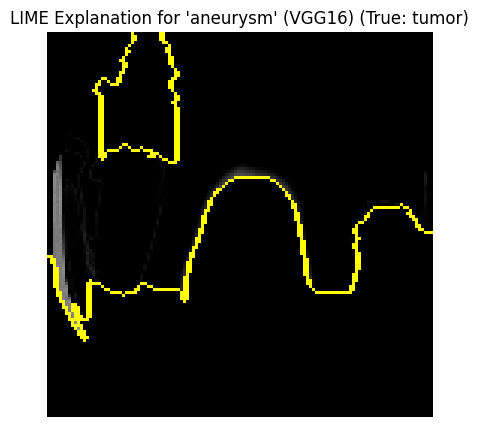

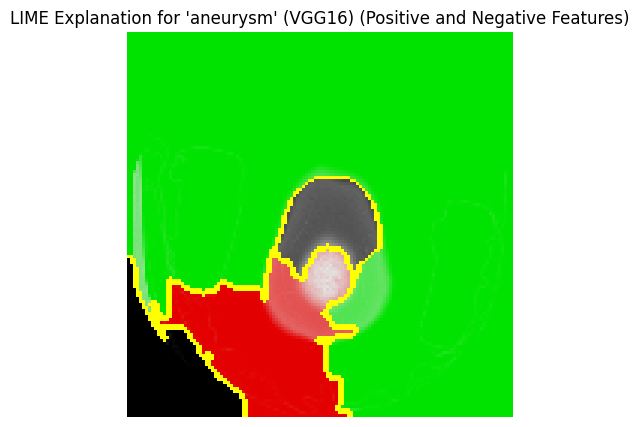

In [ ]:
import cv2 # For reading image in original format for LIME

# Select an example image from the test set (using the same one as Grad-CAM for consistency)
example_index = 0
example_img_path = X_test.iloc[example_index]
example_true_label = y_test.iloc[example_index]

# Load the original image for LIME (LIME expects images in [0, 255] range as input)
img_for_lime = cv2.imread(example_img_path)
img_for_lime = cv2.cvtColor(img_for_lime, cv2.COLOR_BGR2RGB)
img_for_lime = cv2.resize(img_for_lime, (IMG_WIDTH, IMG_HEIGHT))

# Predict with the model for display
img_array_for_model = tf.expand_dims(tf.cast(img_for_lime, tf.float32) / 255.0, 0)
predictions = vgg16_fl_model.predict(img_array_for_model, verbose=0)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = reverse_label_mapping[predicted_class_index]
true_class_name = reverse_label_mapping[example_true_label]

print(f"\nAnalyzing image with LIME for VGG16: {example_img_path}")
print(f"True label: {true_class_name}")
print(f"Predicted label: {predicted_class_name} (Confidence: {predictions[0][predicted_class_index]:.4f})")

# Generate explanation for the predicted class
# hide_color=0 means that 'background' is black (default for images)
# num_samples: number of perturbed samples to generate
explanation = explainer.explain_instance(
    img_for_lime,
    lime_predict_fn_vgg16, # Use the VGG16 specific prediction function
    top_labels=1, # We only care about the top predicted class
    hide_color=0,
    num_samples=1000 # More samples generally lead to better explanations
)

# Get image and mask for the top predicted class
image_lime, mask_lime = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5, # Show top 5 features
    hide_rest=True
)

plt.figure(figsize=(10, 5))
plt.imshow(mark_boundaries(image_lime / 255.0, mask_lime))
plt.title(f"LIME Explanation for '{predicted_class_name}' (VGG16) (True: {true_class_name})")
plt.axis('off')
plt.show()

image_lime_neg, mask_lime_neg = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=10, # Show top 10 features (positive and negative)
    hide_rest=False
)

plt.figure(figsize=(10, 5))
plt.imshow(mark_boundaries(image_lime_neg / 255.0, mask_lime_neg))
plt.title(f"LIME Explanation for '{predicted_class_name}' (VGG16) (Positive and Negative Features)")
plt.axis('off')
plt.show()